# Exploratory Data Analysis (EDA)

In this notebook, exploratory data analysis is performed on the cleaned global market dataset to uncover trends, patterns, and relationships within the data.

The objective of this analysis is to gain a deeper understanding of market behavior across different asset classes, regions, and time periods before drawing conclusions or developing predictive models.

#### The objectives of this notebook are:

- Examine the overall structure of the cleaned dataset
- Generate descriptive statistics for key numerical variables
- Analyze the distribution of market prices and trading volume
- Explore the composition of assets by type and region
- Identify trends and patterns over time
- Investigate relationships between numerical features
- Visualize market behavior during major economic events
- Extract preliminary insights to support further analysis


In [1]:
# importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load dataset

df = pd.read_csv("../Data/processed/cleaned_market_data.csv")
df.head()

,date,open,high,low,close,volume,symbol,asset_name,asset_type,region
0,2000-01-03,1469.2500,1478.0000,1438.3600,1455.2200,931800000,^GSPC,S&P500,Stock Index,Global
1,2000-01-03,4186.1899,4192.1899,3989.7100,4131.1499,1510070000,^IXIC,NASDAQ,Stock Index,Global
2,2000-01-03,17057.6992,17426.1602,17057.6992,17369.6309,0,^HSI,HSI,Stock Index,Global
3,2000-01-03,0.0098,0.0099,0.0097,0.0098,0,JPYUSD=X,JPY/USD,Currency,Global
4,2000-01-03,5209.5400,5384.6602,5209.5400,5375.1099,0,^BSESN,SENSEX,Stock Index,Global


## Dataset Overview

Before performing exploratory analysis, it is important to review the structure of the cleaned dataset. This includes examining the number of records, available features, and data types.

In [3]:
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

Number of Rows: 187611
Number of Columns: 10


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 187611 entries, 0 to 187610
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   date        187611 non-null  str    
 1   open        187611 non-null  float64
 2   high        187611 non-null  float64
 3   low         187611 non-null  float64
 4   close       187611 non-null  float64
 5   volume      187611 non-null  int64  
 6   symbol      187611 non-null  str    
 7   asset_name  187611 non-null  str    
 8   asset_type  187611 non-null  str    
 9   region      187611 non-null  str    
dtypes: float64(4), int64(1), str(5)
memory usage: 14.3 MB


### Observation

The cleaned dataset contains financial market data for multiple assets across different regions. The dataset consists of numerical, categorical, and temporal features required for further exploratory analysis.

## Summary Statistics

Descriptive statistics provide an overview of the central tendency, spread, and distribution of numerical variables within the dataset.

In [8]:
df.describe()

,open,high,low,close,volume
count,187611.000000,187611.000000,187611.000000,187611.000000,1.876110e+05
mean,4408.078092,4444.787018,4366.875968,4407.227970,1.247674e+09
std,10646.457796,10750.171471,10531.420024,10644.700449,5.489795e+09
min,-14.000000,0.001200,-40.320000,-37.630000,0.000000e+00
25%,1.152600,1.160200,1.143150,1.152500,0.000000e+00
50%,125.060000,128.666100,122.100000,125.126700,7.182200e+04
75%,3343.026000,3375.043450,3310.429950,3342.126450,2.232844e+08
max,124752.140600,126198.070300,123196.046900,124752.531200,3.509679e+11


### Observation

The summary statistics provide insights into the range and variability of market prices and trading volumes. Significant differences between minimum and maximum values suggest varying scales across different financial assets.

## Asset Composition Analysis

This section examines the composition of the dataset across asset categories and geographic regions.

In [11]:
# unique assets
print("Unique Assets:", df["asset_name"].nunique())

Unique Assets: 34


In [12]:
# unique assets type
df["asset_type"].value_counts()

asset_type
Stock Index       63610
Commodity         49965
Currency          47629
Cryptocurrency    26407
Name: count, dtype: int64

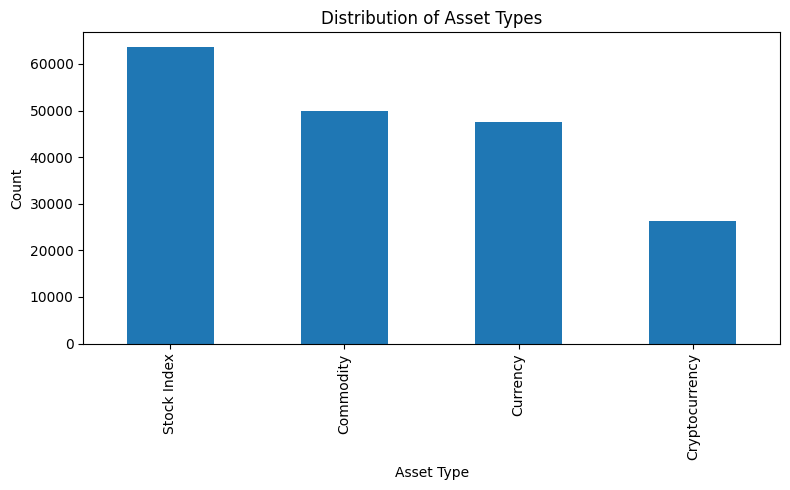

In [13]:
plt.figure(figsize=(8,5))

df["asset_type"].value_counts().plot(kind="bar")

plt.title("Distribution of Asset Types")
plt.xlabel("Asset Type")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

### Observation

The dataset contains multiple asset categories distributed globally. This diversity allows for a broad analysis of financial market behavior across different asset classes.

## Market Coverage Analysis

Understanding the temporal coverage of the dataset is important before performing trend analysis. This section examines the time span covered by the dataset and its representation across different market periods.

In [21]:
# convert date column to datetime

df["date"] = pd.to_datetime(df["date"])

start_date = df["date"].min()
end_date = df["date"].max()

print("Start Date :", start_date.date())
print("End Date   :", end_date.date())
print("Total Years:", round((end_date - start_date).days / 365, 2))

Start Date : 2000-01-03
End Date   : 2026-05-29
Total Years: 26.42


In [22]:
df["year"] = df["date"].dt.year

records_per_year = (
    df["year"]
    .value_counts()
    .sort_index()
)

records_per_year.head()

year
2000    3124
2001    4261
2002    4491
2003    4575
2004    5824
Name: count, dtype: int64

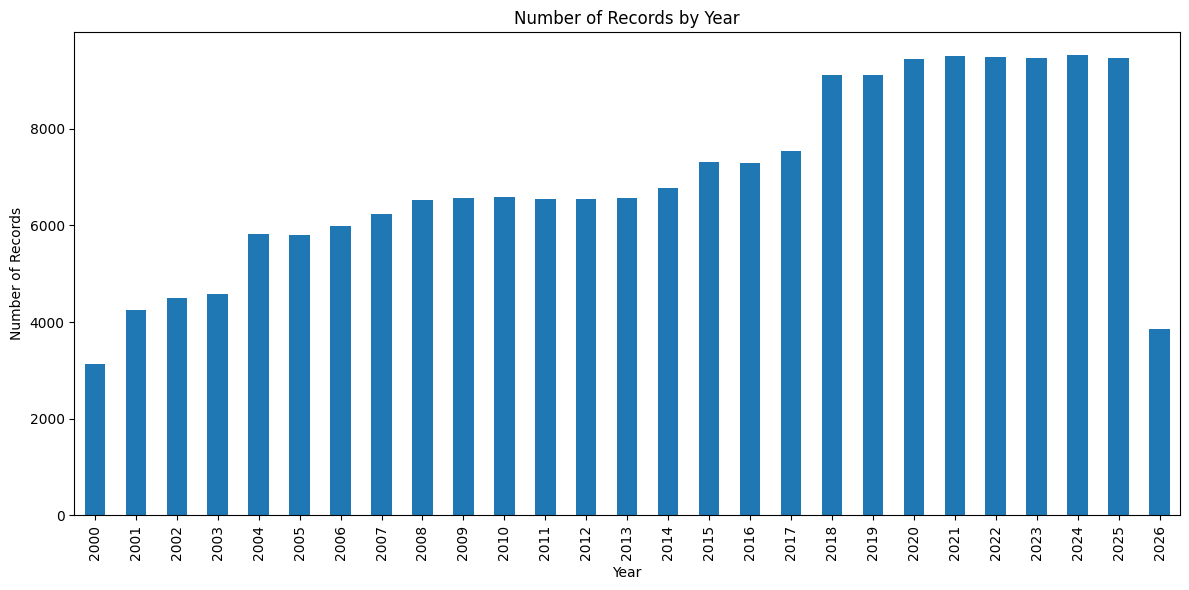

In [23]:
plt.figure(figsize=(12,6))

records_per_year.plot(kind="bar")

plt.title("Number of Records by Year")
plt.xlabel("Year")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

### Observation

The dataset covers the period from 2000 to 2026 and shows a generally increasing number of records over time. Record counts rise steadily from the early 2000s, indicating an expansion in market coverage and asset representation. The highest number of records is observed between 2020 and 2025, reflecting the broadest market coverage during the study period. The lower count for 2026 is expected, as the dataset contains data only up to May 2026 rather than the complete year.

## Trading Volume Analysis

Trading volume is an important indicator of market activity and liquidity. Analyzing volume patterns can help identify periods of increased investor participation and market interest.

In [24]:
df["volume"].describe()

count    1.876110e+05
mean     1.247674e+09
std      5.489795e+09
min      0.000000e+00
25%      0.000000e+00
50%      7.182200e+04
75%      2.232844e+08
max      3.509679e+11
Name: volume, dtype: float64

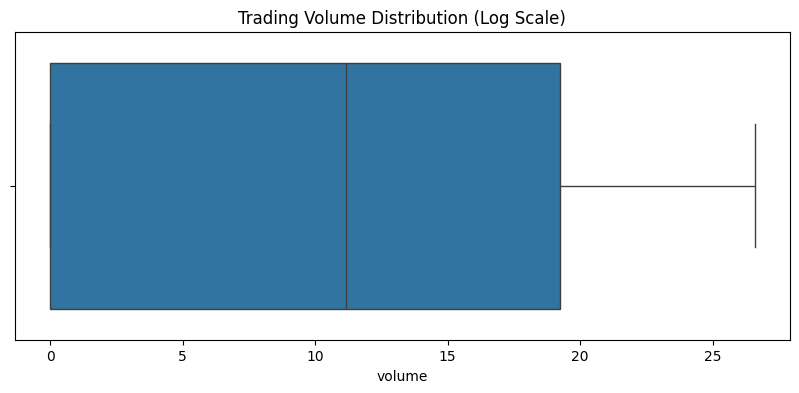

In [32]:
plt.figure(figsize=(10,4))

sns.boxplot(
    x=np.log1p(df["volume"])
)

plt.title("Trading Volume Distribution (Log Scale)")

plt.show()

#### Observation

The boxplot reveals a wide spread in trading volume across observations and highlights the presence of numerous high-volume outliers. These extreme values are expected in financial market data and likely correspond to highly liquid assets or periods of elevated market activity. The use of a logarithmic scale improves visibility of the overall distribution while reducing the influence of extreme values.

In [26]:
top_volume = (
    df.groupby("asset_name")["volume"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_volume

asset_name
Bitcoin     95140825495054
Ethereum    47484208040675
S&P500      22921812500000
NASDAQ      19110465960000
HSI         10549980300000
Ripple       8953618671605
FTSE100      7064569250000
Solana       5402507050706
Litecoin     5192510970160
Dogecoin     3982404922403
Name: volume, dtype: int64

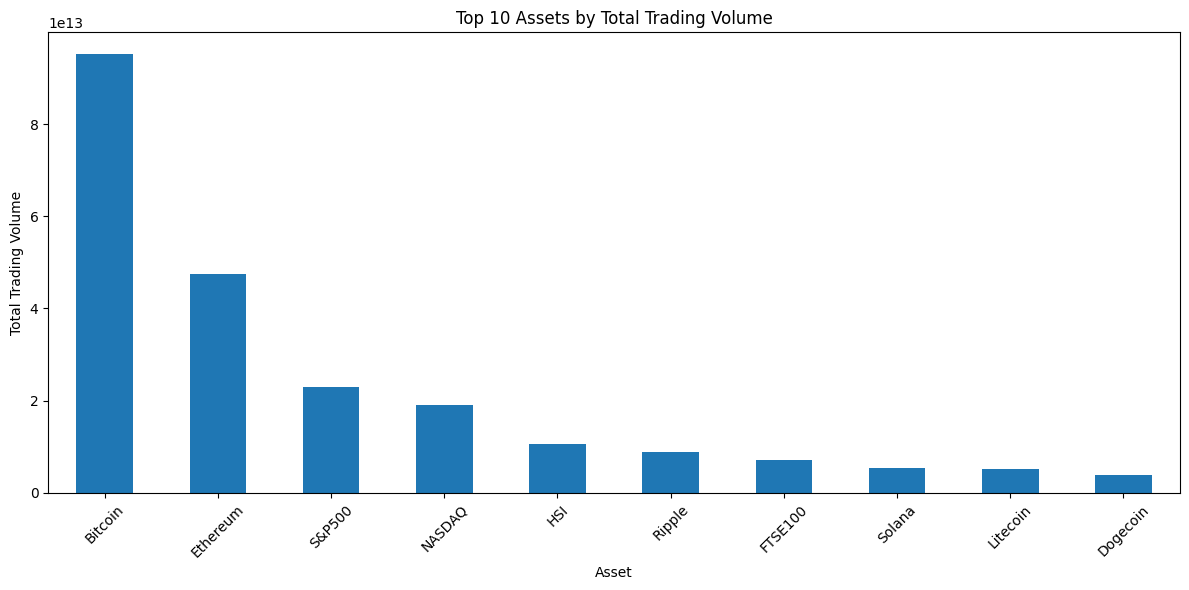

In [27]:
plt.figure(figsize=(12,6))

top_volume.plot(kind="bar")

plt.title("Top 10 Assets by Total Trading Volume")
plt.xlabel("Asset")
plt.ylabel("Total Trading Volume")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### Observation

Bitcoin dominates the dataset in terms of total trading volume, with a volume nearly twice that of Ethereum, the second-ranked asset. Among traditional financial assets, the S&P 500 and NASDAQ indices account for the highest trading activity, reflecting their importance in global financial markets. The presence of multiple cryptocurrencies, including Bitcoin, Ethereum, Ripple, Solana, Litecoin, and Dogecoin, among the top-ranked assets highlights the substantial growth and market participation within the cryptocurrency sector during the study period.

In [28]:
avg_volume_type = (
    df.groupby("asset_type")["volume"]
      .mean()
      .sort_values(ascending=False)
)

avg_volume_type

asset_type
Cryptocurrency    6.554379e+09
Stock Index       9.588466e+08
Commodity         7.247133e+04
Currency          0.000000e+00
Name: volume, dtype: float64

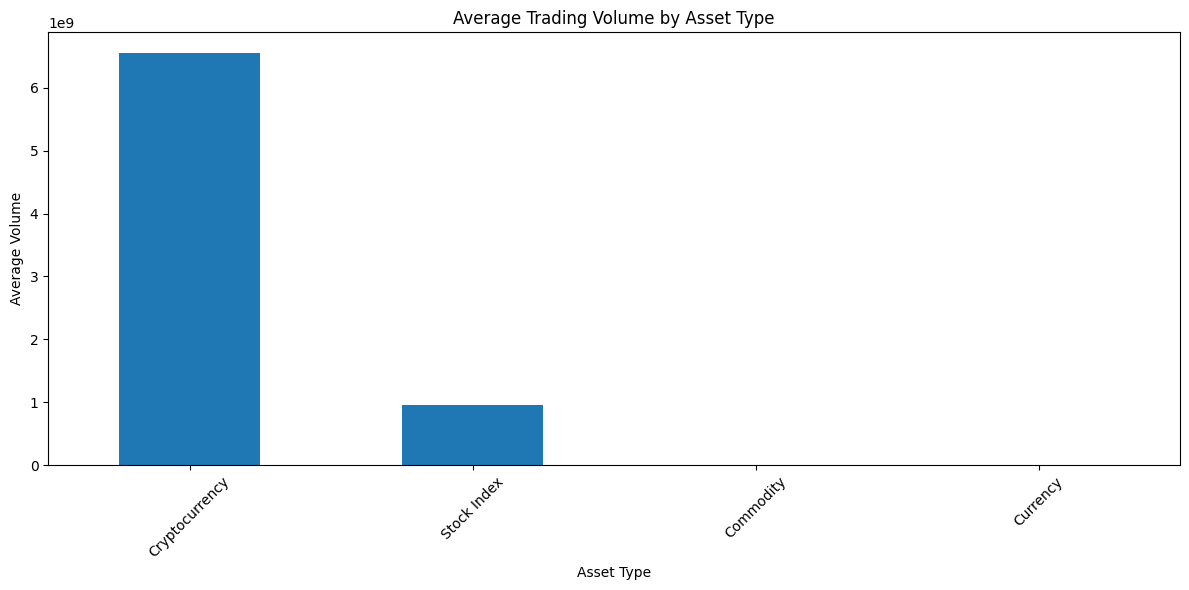

In [29]:
plt.figure(figsize=(12,6))

avg_volume_type.plot(kind="bar")

plt.title("Average Trading Volume by Asset Type")
plt.xlabel("Asset Type")
plt.ylabel("Average Volume")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### Observation

Cryptocurrencies exhibit the highest average trading volume among all asset types in the dataset, significantly exceeding stock indices, commodities, and currencies. Stock indices rank second but remain substantially below cryptocurrencies in terms of average market activity. The relatively low average volumes observed for commodities and currency pairs suggest lower reported trading activity compared to the highly liquid cryptocurrency market.

In [33]:
asset_counts = df["asset_type"].value_counts()

avg_volume = (
    df.groupby("asset_type")["volume"]
      .mean()
)

comparison = pd.DataFrame({
    "count": asset_counts,
    "avg_volume": avg_volume
}).loc[asset_counts.index]

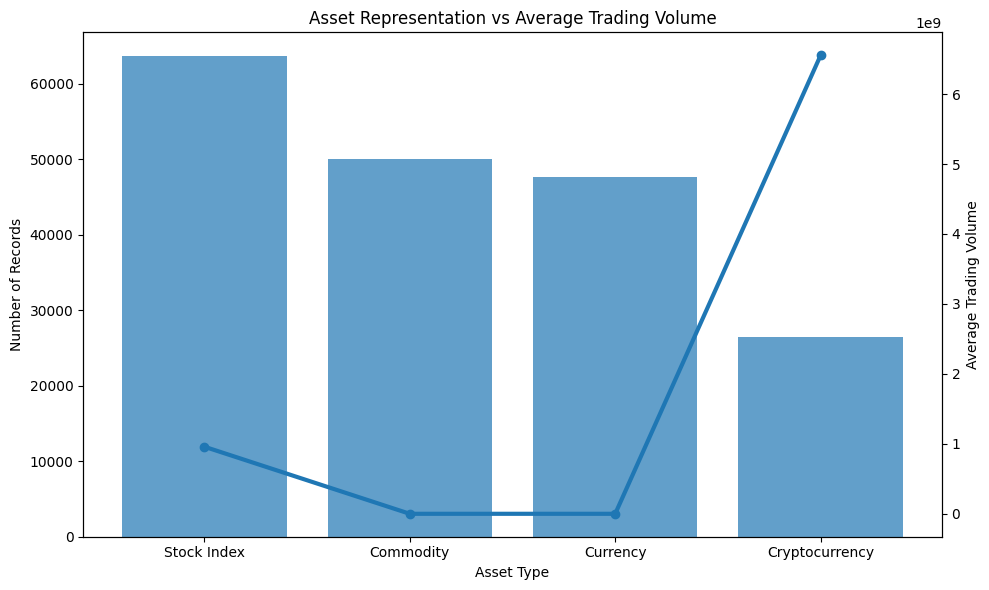

In [34]:
fig, ax1 = plt.subplots(figsize=(10,6))

# Bar chart for counts
ax1.bar(
    comparison.index,
    comparison["count"],
    alpha=0.7,
    label="Record Count"
)

ax1.set_ylabel("Number of Records")
ax1.set_xlabel("Asset Type")

# Second axis for volume
ax2 = ax1.twinx()

ax2.plot(
    comparison.index,
    comparison["avg_volume"],
    marker="o",
    linewidth=3,
    label="Average Trading Volume"
)

ax2.set_ylabel("Average Trading Volume")

plt.title(
    "Asset Representation vs Average Trading Volume"
)

plt.tight_layout()
plt.show()

#### Observation

Although cryptocurrencies represent the smallest asset category in terms of the number of records, they exhibit by far the highest average trading volume. In contrast, stock indices, commodities, and currencies account for a larger share of observations but generate substantially lower trading activity on average. This indicates that cryptocurrency markets experience significantly higher trading intensity relative to their representation in the dataset.

### Overall Observation

The trading volume analysis reveals significant differences in market activity across asset types and individual assets. Trading volume is highly concentrated among a small number of assets, with Bitcoin and Ethereum accounting for a substantial share of total market activity. While stock indices constitute the largest portion of the dataset by record count, cryptocurrencies demonstrate considerably higher average trading volumes, indicating greater trading intensity and market participation. Furthermore, the distribution of trading volume is highly skewed, with a small number of observations exhibiting exceptionally large volumes compared to the majority of records. Overall, the results highlight the dominant role of major cryptocurrencies in driving trading activity within the dataset despite their relatively smaller representation.

#### Key Findings

- Trading volume is unevenly distributed across assets and asset types.
- Bitcoin records the highest total trading volume, followed by Ethereum.
- Cryptocurrencies exhibit the highest average trading volume among all asset categories.
- Stock indices have the largest number of records but lower average trading activity than cryptocurrencies.
- Trading volume distribution is highly right-skewed, indicating the presence of a small number of extremely high-volume observations.
- A relatively small group of assets accounts for a substantial portion of total market activity.